# Maturity-Based Visibility Evaluator

This notebook evaluates the four maturity-based visibility conditions and produces only the six unified figures requested:

1. Rank, one aggregate line.
2. Rank, two sender-type lines: G sender vs. S sender.
3. Rank, four directional lines: GG, GS, SG, SS.
4. Diversity, one aggregate line.
5. Diversity, two sender-type lines: G sender vs. S sender.
6. Diversity, four directional lines: GG, GS, SG, SS.

All plotted values are averaged across K. Rank is inverted because a smaller rank indicates a better solution.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
from pathlib import Path

legend_properties = {"weight": "bold"}

# =========================
# Configuration
# =========================
# Change this path to the folder that contains the saved pickle outputs.
result_folder = Path(r"/Volumes/T7/data/gst-0112-26/Maturity_interval_10_2")

agent_num = 200

# This list follows the current maturity-running script.
# Add 0.0 here only if you also generated the corresponding output files.
maturity_threshold_list = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# The uploaded running script currently saves files with interval_20 in the filename.
visibility_interval = 10

prefixes = ["gg", "gs", "sg", "ss"]
condition_labels = {
    "gg": "G → G",
    "gs": "G → S",
    "sg": "S → G",
    "ss": "S → S",
}

# Only these two DVs are needed for the six requested figures.
dv_labels = {
    "breakthrough_rank": "Best solution rank",
    "diversity": "Diversity",
}

# Black-and-white line styles for publication-friendly figures.
four_line_styles = {
    "gg": {"marker": "o", "linestyle": "-",  "label": "G → G"},
    "gs": {"marker": "s", "linestyle": "--", "label": "G → S"},
    "sg": {"marker": "v", "linestyle": "-.", "label": "S → G"},
    "ss": {"marker": "^", "linestyle": ":",  "label": "S → S"},
}

sender_styles = {
    "G": {"marker": "o", "linestyle": "-",  "label": "G as sender"},
    "S": {"marker": "v", "linestyle": "--", "label": "S as sender"},
}


In [2]:
# =========================
# Load results
# =========================
def load_pickle(path):
    with open(path, "rb") as infile:
        return pickle.load(infile)


def result_file(prefix, maturity_threshold, dv, interval=visibility_interval):
    """Return the expected result path for the current interval-based maturity scripts."""
    return result_folder / (
        f"{prefix}_maturity_threshold_{maturity_threshold}_interval_{interval}_"
        f"{dv}_across_K_size_{agent_num}"
    )


def legacy_result_file(prefix, maturity_threshold, dv):
    """Fallback path for older maturity scripts that did not include visibility interval."""
    return result_folder / f"{prefix}_maturity_threshold_{maturity_threshold}_{dv}_across_K_size_{agent_num}"


def resolve_result_file(prefix, maturity_threshold, dv):
    path = result_file(prefix, maturity_threshold, dv)
    if path.exists():
        return path

    legacy_path = legacy_result_file(prefix, maturity_threshold, dv)
    if legacy_path.exists():
        return legacy_path

    return path


def diagnose_folder():
    print("Result folder:", result_folder)
    print("Folder exists:", result_folder.exists())

    available_files = sorted([p.name for p in result_folder.iterdir()]) if result_folder.exists() else []
    print("Number of files in folder:", len(available_files))
    print("First 10 files:")
    for name in available_files[:10]:
        print("  ", name)


def load_maturity_visibility_results(prefixes=prefixes, strict=True):
    """Load maturity-threshold results into data[prefix][dv].

    Each data[prefix][dv] array has shape:
        maturity threshold × K

    The plotting cells below average across K, so they are robust to whether
    the running scripts use K=[0,...,8] or K=[1,...,8], as long as each file
    has a consistent K dimension.

    The loader first looks for the current interval-based filename, for example:
        gg_maturity_threshold_0.1_interval_20_breakthrough_rank_across_K_size_200

    It also supports the older filename without interval as a fallback.
    """
    data = {}
    missing_files = []

    for prefix in prefixes:
        data[prefix] = {}

        for dv in dv_labels:
            rows = []

            for maturity_threshold in maturity_threshold_list:
                path = resolve_result_file(prefix, maturity_threshold, dv)

                if not path.exists():
                    missing_files.append(path)
                    continue

                values = np.asarray(load_pickle(path), dtype=float)
                rows.append(values)

            if rows:
                data[prefix][dv] = np.vstack(rows)

    if missing_files:
        print("\nMissing files:")
        for path in missing_files[:30]:
            print("  -", path.name)

        if len(missing_files) > 30:
            print(f"  ... and {len(missing_files) - 30} more")

        print("\nPossible causes:")
        print("1. result_folder is not the folder where the scripts saved outputs.")
        print("2. Some scripts have not finished.")
        print("3. agent_num or visibility_interval differs from the saved filenames.")
        print("4. maturity_threshold_list differs from the generated threshold values.")
        print("5. File prefix is different, e.g., gg/gs/sg/ss.")

        if strict:
            raise FileNotFoundError("Some expected result files are missing.")

    return data


diagnose_folder()
data = load_maturity_visibility_results(strict=True)

print("\nLoaded data shapes:")
for prefix in prefixes:
    for dv in dv_labels:
        if dv in data[prefix]:
            print(prefix, dv, data[prefix][dv].shape)


Result folder: /Volumes/T7/data/gst-0112-26/Maturity_interval_10_2
Folder exists: True
Number of files in folder: 366
First 10 files:
   ._Crowd.py
   ._Evaluator.ipynb
   ._G_send_to_G_maturity_visibility.py
   ._G_send_to_S_maturity_visibility.py
   ._Generalist.py
   ._Landscape.py
   ._S_send_to_G_maturity_visibility.py
   ._S_send_to_S_maturity_visibility.py
   ._Specialist.py
   ._figure_1_rank_one_line.png

Loaded data shapes:
gg breakthrough_rank (9, 8)
gg diversity (9, 8)
gs breakthrough_rank (9, 8)
gs diversity (9, 8)
sg breakthrough_rank (9, 8)
sg diversity (9, 8)
ss breakthrough_rank (9, 8)
ss diversity (9, 8)


In [3]:
# =========================
# Plotting helpers
# =========================
def format_axis(ax, y_label, title, invert_y=False):
    for spine in ["left", "right", "top", "bottom"]:
        ax.spines[spine].set_linewidth(1.5)

    ax.set_xlabel("Maturity threshold", fontweight="bold", fontsize=12)
    ax.set_ylabel(y_label, fontweight="bold", fontsize=12)
    ax.set_title(title, fontweight="bold", fontsize=13)
    ax.set_xticks(maturity_threshold_list)
    ax.grid(alpha=0.25)

    if invert_y:
        ax.invert_yaxis()


def save_and_show(fig, filename):
    output_path = result_folder / filename
    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)


def mean_across_K(prefix, dv):
    return data[prefix][dv].mean(axis=1)


def overall_mean(dv):
    """Average across GG, GS, SG, SS and across K."""
    return np.mean([mean_across_K(prefix, dv) for prefix in prefixes], axis=0)


def sender_mean(sender, dv):
    """Average by sender type.

    G sender = average of GG and GS.
    S sender = average of SG and SS.
    """
    if sender == "G":
        selected = ["gg", "gs"]
    elif sender == "S":
        selected = ["sg", "ss"]
    else:
        raise ValueError("sender must be 'G' or 'S'.")

    return np.mean([mean_across_K(prefix, dv) for prefix in selected], axis=0)


def plot_one_line(dv, y_label, title, filename, invert_y=False):
    fig, ax = plt.subplots(figsize=(7.2, 5.0))
    ax.plot(
        maturity_threshold_list, overall_mean(dv),
        marker="o", linestyle="-", color="black",
        linewidth=2.5, markersize=7,
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.5,
        label="Average across four conditions"
    )
    format_axis(ax, y_label=y_label, title=title, invert_y=invert_y)
    ax.legend(prop=legend_properties, frameon=False, loc="best")
    save_and_show(fig, filename)


def plot_sender_lines(dv, y_label, title, filename, invert_y=False):
    fig, ax = plt.subplots(figsize=(7.2, 5.0))

    for sender in ["G", "S"]:
        style = sender_styles[sender]
        ax.plot(
            maturity_threshold_list, sender_mean(sender, dv),
            marker=style["marker"], linestyle=style["linestyle"], color="black",
            linewidth=2.5, markersize=7,
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=1.5,
            label=style["label"]
        )

    format_axis(ax, y_label=y_label, title=title, invert_y=invert_y)
    ax.legend(prop=legend_properties, frameon=False, loc="best")
    save_and_show(fig, filename)


def plot_four_lines(dv, y_label, title, filename, invert_y=False):
    fig, ax = plt.subplots(figsize=(7.2, 5.0))

    for prefix in prefixes:
        style = four_line_styles[prefix]
        ax.plot(
            maturity_threshold_list, mean_across_K(prefix, dv),
            marker=style["marker"], linestyle=style["linestyle"], color="black",
            linewidth=2.5, markersize=7,
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=1.5,
            label=style["label"]
        )

    format_axis(ax, y_label=y_label, title=title, invert_y=invert_y)
    ax.legend(prop=legend_properties, frameon=False, loc="best")
    save_and_show(fig, filename)


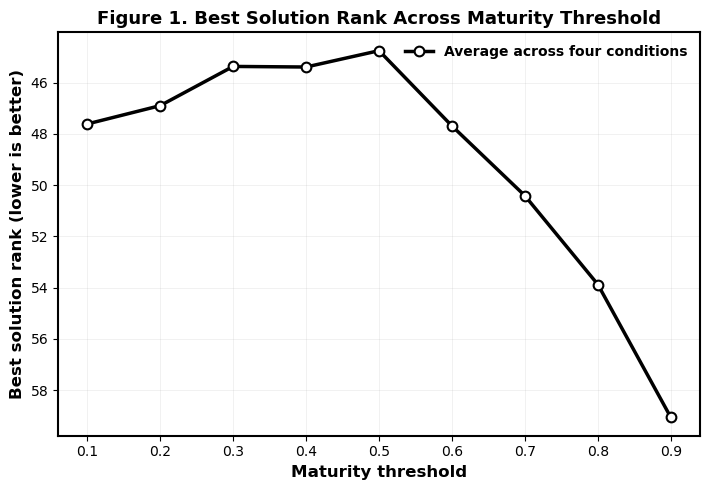

Saved: /Volumes/T7/data/gst-0112-26/Maturity_interval_10_2/figure_1_rank_one_line.png


In [4]:
# =========================
# Figure 1: One line — Rank across maturity threshold
# =========================
plot_one_line(
    dv="breakthrough_rank",
    y_label="Best solution rank (lower is better)",
    title="Figure 1. Best Solution Rank Across Maturity Threshold",
    filename="figure_1_rank_one_line.png",
    invert_y=True,
)


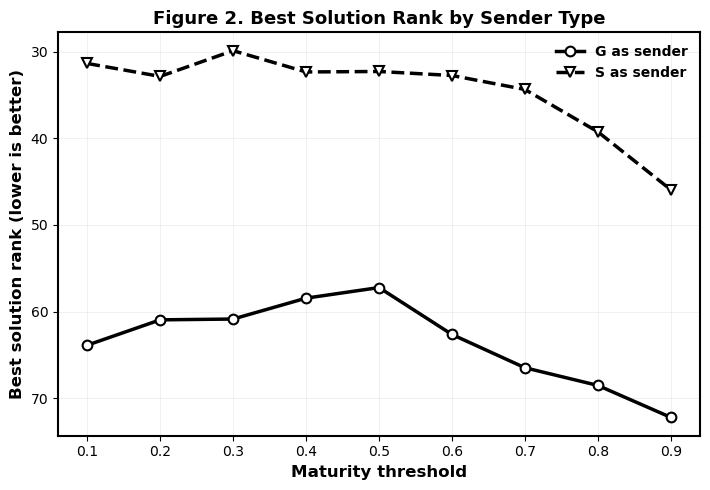

Saved: /Volumes/T7/data/gst-0112-26/Maturity_interval_10_2/figure_2_rank_sender_type.png


In [5]:
# =========================
# Figure 2: Two lines — Rank by sender type
# =========================
plot_sender_lines(
    dv="breakthrough_rank",
    y_label="Best solution rank (lower is better)",
    title="Figure 2. Best Solution Rank by Sender Type",
    filename="figure_2_rank_sender_type.png",
    invert_y=True,
)


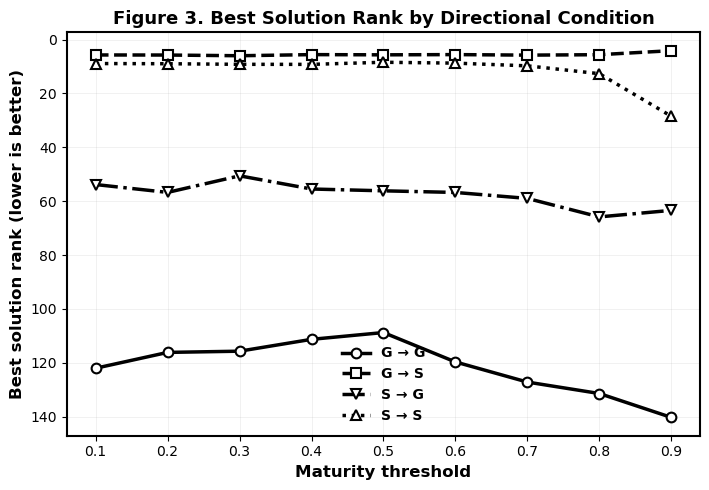

Saved: /Volumes/T7/data/gst-0112-26/Maturity_interval_10_2/figure_3_rank_four_conditions.png


In [6]:
# =========================
# Figure 3: Four lines — Rank by directional condition
# =========================
plot_four_lines(
    dv="breakthrough_rank",
    y_label="Best solution rank (lower is better)",
    title="Figure 3. Best Solution Rank by Directional Condition",
    filename="figure_3_rank_four_conditions.png",
    invert_y=True,
)


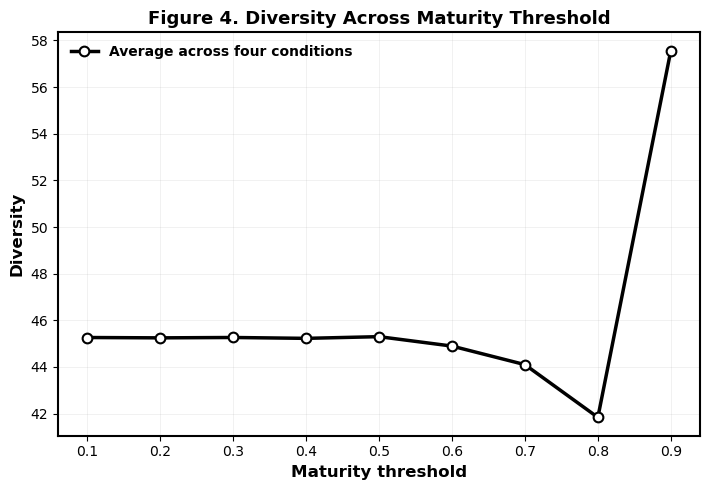

Saved: /Volumes/T7/data/gst-0112-26/Maturity_interval_10_2/figure_4_diversity_one_line.png


In [7]:
# =========================
# Figure 4: One line — Diversity across maturity threshold
# =========================
plot_one_line(
    dv="diversity",
    y_label="Diversity",
    title="Figure 4. Diversity Across Maturity Threshold",
    filename="figure_4_diversity_one_line.png",
    invert_y=False,
)

# When the maturity threshold is extremely  high, visibility becomes highly selective and sparse. Solvers receive fewer shared cues, so they converge less (less joint confirmation), remain more dispersed (highly mutual deviation), and fail to benefit from broad recombination. Diversity increases, but this diversity is not productive enough to generate better breakthrough ranks.
# This is a good case for the distinction between diversity metric and the breakthrough metric.
# Strict disclosure filters select solutions that appear mature to senders but may be locally constrained and less generative for receivers.

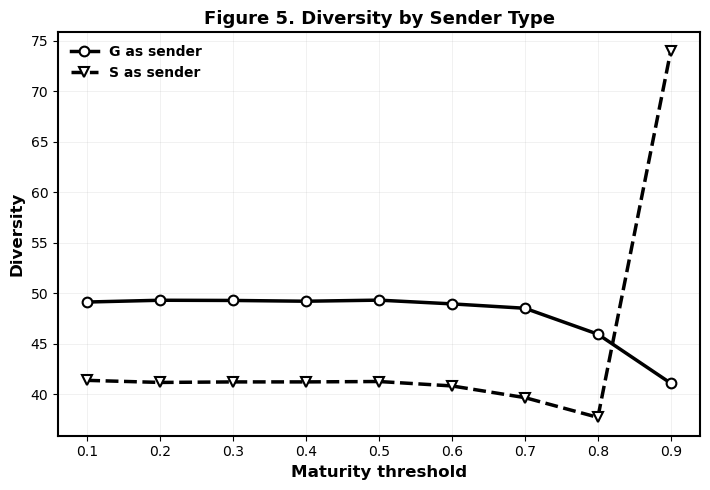

Saved: /Volumes/T7/data/gst-0112-26/Maturity_interval_10_2/figure_5_diversity_sender_type.png


In [8]:
# =========================
# Figure 5: Two lines — Diversity by sender type
# =========================
plot_sender_lines(
    dv="diversity",
    y_label="Diversity",
    title="Figure 5. Diversity by Sender Type",
    filename="figure_5_diversity_sender_type.png",
    invert_y=False,
)


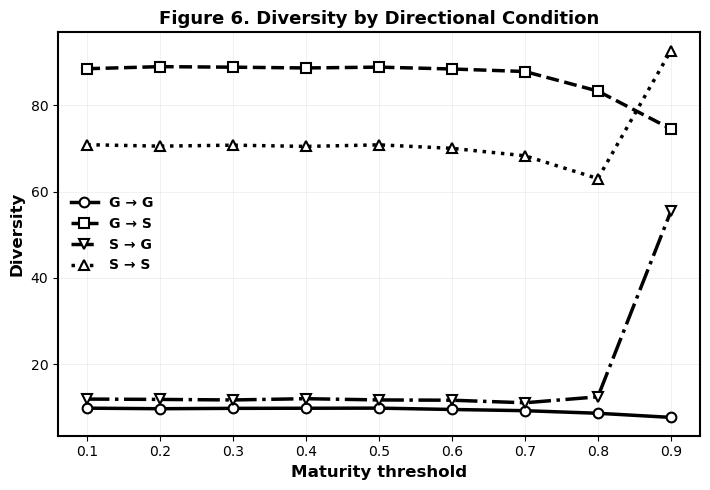

Saved: /Volumes/T7/data/gst-0112-26/Maturity_interval_10_2/figure_6_diversity_four_conditions.png


In [9]:
# =========================
# Figure 6: Four lines — Diversity by directional condition
# =========================
plot_four_lines(
    dv="diversity",
    y_label="Diversity",
    title="Figure 6. Diversity by Directional Condition",
    filename="figure_6_diversity_four_conditions.png",
    invert_y=False,
)


In [10]:
# =========================
# Optional helper: inspect exact plotted values as tables
# =========================
def maturity_table(dv="breakthrough_rank"):
    """Return the values used in the one-line, sender-type, and four-condition figures."""
    table = {
        "overall": overall_mean(dv).round(4).tolist(),
        "G_sender": sender_mean("G", dv).round(4).tolist(),
        "S_sender": sender_mean("S", dv).round(4).tolist(),
    }
    for prefix in prefixes:
        table[prefix] = mean_across_K(prefix, dv).round(4).tolist()

    columns = [f"maturity={value}" for value in maturity_threshold_list]
    return table, columns


rank_table, columns = maturity_table("breakthrough_rank")
diversity_table, _ = maturity_table("diversity")

print("Columns:")
print(columns)
print("\nRank table:")
for key, values in rank_table.items():
    print(key, values)

print("\nDiversity table:")
for key, values in diversity_table.items():
    print(key, values)


Columns:
['maturity=0.1', 'maturity=0.2', 'maturity=0.3', 'maturity=0.4', 'maturity=0.5', 'maturity=0.6', 'maturity=0.7', 'maturity=0.8', 'maturity=0.9']

Rank table:
overall [47.6181, 46.9031, 45.3727, 45.3956, 44.7578, 47.6956, 50.4189, 53.8822, 59.0666]
G_sender [63.8666, 60.9438, 60.8506, 58.4412, 57.2203, 62.6322, 66.4681, 68.5091, 72.1947]
S_sender [31.3697, 32.8625, 29.8947, 32.35, 32.2953, 32.7591, 34.3697, 39.2553, 45.9384]
gg [122.0069, 116.1338, 115.685, 111.285, 108.7619, 119.6738, 127.1469, 131.3919, 140.2562]
gs [5.7262, 5.7538, 6.0162, 5.5975, 5.6787, 5.5906, 5.7894, 5.6262, 4.1331]
sg [53.8262, 56.7438, 50.59, 55.4825, 56.1569, 56.7588, 58.9744, 65.8369, 63.4125]
ss [8.9131, 8.9812, 9.1994, 9.2175, 8.4338, 8.7594, 9.765, 12.6738, 28.4644]

Diversity table:
overall [45.2627, 45.2478, 45.2634, 45.2261, 45.2991, 44.895, 44.0995, 41.8381, 57.5595]
G_sender [49.1403, 49.3156, 49.2953, 49.2194, 49.3269, 48.9563, 48.5231, 45.9563, 41.0966]
S_sender [41.385, 41.18, 41.2316, 41.